In [23]:
# Cellule 1 - Importer les bibliotheques
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [ ]:
# Cellule 2 - Charger les logs depuis PostgreSQL (production) ou JSONL (local)
import os
from pathlib import Path

DATABASE_URL = os.getenv("DATABASE_URL", "")

if DATABASE_URL:
    from sqlalchemy import create_engine
    engine = create_engine(DATABASE_URL)
    df = pd.read_sql(
        "SELECT timestamp, request_id, user_id, variant, model_version, "
        "execution_mode, prediction, latency_ms, features "
        "FROM predictions ORDER BY timestamp",
        engine,
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    print(f"Source : PostgreSQL ({len(df)} lignes)")
else:
    log_path = Path("../logs/ab_predictions.jsonl")
    df = pd.read_json(log_path, lines=True)
    print(f"Source : JSONL local ({len(df)} lignes)")

print(df.shape)
df.head()

In [25]:
# Cellule 3 - Verifier les colonnes
df.columns

Index(['request_id', 'user_id', 'variant', 'model_version', 'execution_mode',
       'prediction', 'latency_ms', 'features', 'timestamp'],
      dtype='object')

In [26]:
# Cellule 4 - Compter le nombre de requetes par variante
df["variant"].value_counts()

variant
A    72
B     2
Name: count, dtype: int64

In [27]:
# Cellule 5 - Comparer les predictions moyennes
df.groupby("variant")["prediction"].agg(["count", "mean", "std", "min", "max"])


,count,mean,std,min,max
variant,,,,,
A,72,2.343309,0.23793,1.959114,2.500000
B,2,1.815061,0.00000,1.815061,1.815061


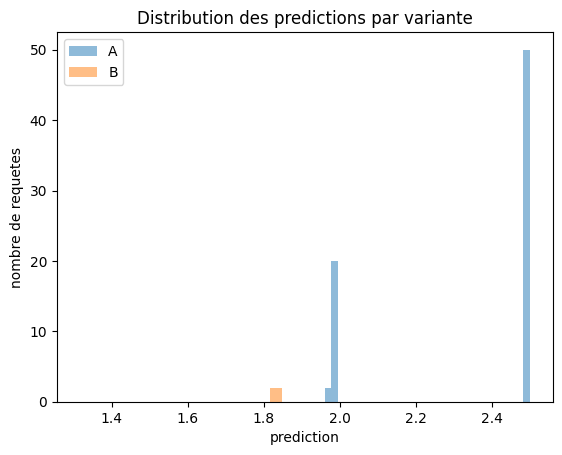

In [28]:
# Cellule 6 - Visualiser les distributions
for variant in ["A", "B"]:
    subset = df[df["variant"] == variant]
    plt.hist(subset["prediction"], alpha=0.5, bins=30, label=variant)

plt.legend()
plt.title("Distribution des predictions par variante")
plt.xlabel("prediction")
plt.ylabel("nombre de requetes")
plt.show()

In [29]:
# Cellule 7 - Comparer la latence
df.groupby("variant")["latency_ms"].agg(["count", "mean", "std", "max"])

,count,mean,std,max
variant,,,,
A,72,58.592778,407.701631,3429.53
B,2,362.380000,492.796858,710.84


In [30]:
# Cellule 8 - Faire un T-test sur les predictions
group_A = df[df["variant"] == "A"]["prediction"]
group_B = df[df["variant"] == "B"]["prediction"]

stat, pvalue = ttest_ind(group_A, group_B, equal_var=False)

print("statistique =", stat)
print("p-value =", pvalue)


d:\Projects\ml-housing-project\mon_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


statistique = 18.838857712292768
p-value = 2.4680695857680736e-29


In [31]:
# Cellule 9 - Ajouter une ground truth simulee
df["actual_value"] = df["prediction"] + np.random.normal(
    loc=0,
    scale=0.3,
    size=len(df),
)

df.head()


,request_id,user_id,variant,model_version,execution_mode,prediction,latency_ms,features,timestamp,actual_value
0,20e9a671-7de2-4c8d-ad34-4324871e28cb,anonymous,A,model_v1,ab_registry,1.959114,3429.53,"{'median_income': 3.5, 'housing_median_age': 2...",2026-05-10 17:27:42.816912+00:00,1.921326
1,390d3ab2-1867-4608-a95a-7a7d7efd3286,anonymous,A,legacy_single_model,legacy_fallback,2.500000,0.62,"{'median_income': 3.5, 'housing_median_age': 2...",2026-05-10 17:28:13.315746+00:00,2.462740
2,45728ea4-e96e-43d5-b689-fb752d9e12b8,anonymous,A,legacy_single_model,legacy_fallback,2.500000,0.56,"{'median_income': 3.5, 'housing_median_age': 2...",2026-05-10 17:28:33.318671+00:00,2.757853
3,91f5228a-2c50-4876-ad77-c8224f5c8f66,anonymous,A,legacy_single_model,legacy_fallback,2.500000,0.48,"{'median_income': 3.5, 'housing_median_age': 2...",2026-05-10 17:29:16.838754+00:00,2.841147
4,22d50b18-e44c-455f-b2a8-e2ca179ffb9e,anonymous,A,legacy_single_model,legacy_fallback,2.500000,0.52,"{'median_income': 3.5, 'housing_median_age': 2...",2026-05-10 17:50:01.687258+00:00,2.753681


In [32]:
# Cellule 10 - Calculer l'erreur absolue par variante
df["absolute_error"] = (df["actual_value"] - df["prediction"]).abs()

df.groupby("variant")["absolute_error"].agg(["count", "mean", "std"])


,count,mean,std
variant,,,
A,72,0.238367,0.172397
B,2,0.315866,0.024538


In [33]:
# Cellule 11 - Faire un T-test sur l'erreur absolue
err_A = df[df["variant"] == "A"]["absolute_error"]
err_B = df[df["variant"] == "B"]["absolute_error"]

stat, pvalue = ttest_ind(err_A, err_B, equal_var=False)

print("statistique erreur =", stat)
print("p-value erreur =", pvalue)


statistique erreur = -2.9006303358653556
p-value erreur = 0.0303430226392051
